# Intraday Patterns: Volume and Volatility Dynamics

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Quantify the intraday volume U-shape across high-, medium-, and low-liquidity
NASDAQ tickers using ITCH-derived trade data, and produce the comparative
30-minute-resolution figures that §3.1 and §3.3 reference.

## Learning Objectives

After completing this notebook, you will be able to:
- Resample tick-level trades into 30-minute volume bars and recognize the
  open/close hump versus midday lull.
- Compare intraday patterns across liquidity tiers (TSLA / mid-tier / illiquid)
  and quantify the open-vs-midday volume ratio.
- Connect the U-shape to feature engineering choices in Chapter 8 (time-of-day
  features, volume-normalized signals).

## Book reference

Section §3.1 (intraday-flow narrative) and Section §3.3 (stylized-facts
subsection on intraday U-shape).

## Prerequisites

- The canonical enriched-trade parquet at
  `output/ch03/nasdaq_itch/trading_activity/trades.parquet` and the matching
  `trade_summary.parquet` (used for liquidity-tier symbol selection); both
  are produced by `05_itch_trading_activity`.

---

## Setup

In [1]:
"""Intraday Patterns — volume and volatility dynamics from NASDAQ ITCH data."""

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from utils.paths import get_output_dir

sns.set_style("whitegrid")

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

In [3]:
# Configuration - Unified output directory structure
# All ITCH-related outputs under a single chapter directory
NASDAQ_ITCH_OUTPUT = get_output_dir(3, "nasdaq_itch")

# Input: Parsed messages from notebook 01
MESSAGE_DIR = NASDAQ_ITCH_OUTPUT / "messages"

# Input: Trade summary from notebook 05 (trading_activity_overview)
TRADING_ACTIVITY_DIR = NASDAQ_ITCH_OUTPUT / "trading_activity"

print(f"Input directory (messages): {MESSAGE_DIR}")
print(f"Input directory (trade summary): {TRADING_ACTIVITY_DIR}")

if not MESSAGE_DIR.exists():
    print(f"\nWARNING: Message directory not found: {MESSAGE_DIR}")
    print("   Run 01_itch_parser first.")

Input directory (messages): 03_market_microstructure/output/nasdaq_itch/messages
Input directory (trade summary): 03_market_microstructure/output/nasdaq_itch/trading_activity


## Load Trade Data

Load outputs from `05_itch_trading_activity`:
- `trade_summary.parquet`: Aggregated stats by ticker (for symbol selection)
- `trades.parquet`: Canonical tick-level trades (for analysis)

Using the canonical trades file ensures we include enriched E/C data
(executions with stock attribution added by notebook 01).

In [4]:
# Load trade summary and canonical trades from notebook 05
TRADE_SUMMARY_PATH = TRADING_ACTIVITY_DIR / "trade_summary.parquet"
TRADES_PATH = TRADING_ACTIVITY_DIR / "trades.parquet"

# Load trade summary for ticker selection
if TRADE_SUMMARY_PATH.exists():
    trade_summary = pl.read_parquet(TRADE_SUMMARY_PATH)
    # Sort explicitly by value to ensure correct selection
    trade_summary = trade_summary.sort("total_value", descending=True)
    # Gate the low-liquidity tier on a minimum number of trades so the
    # comparison panel is not degenerate (single-trade tickers produce
    # collapsed price/volume axes that obscure the intraday shape).
    MIN_TRADES_LOW = 500
    trade_col = next(
        (c for c in ("trade_count", "n_trades", "total_trades") if c in trade_summary.columns),
        None,
    )
    if trade_col is None:
        # Fallback: use top half by total_value if no trade-count column.
        active_summary = trade_summary.head(len(trade_summary) // 2)
    else:
        active_summary = trade_summary.filter(pl.col(trade_col) >= MIN_TRADES_LOW)
    num_syms = len(active_summary)
    high_sym = active_summary["ticker"][0]  # highest value, still traded
    mid_sym = active_summary["ticker"][num_syms // 2]  # middle of active band
    low_sym = active_summary["ticker"][-1]  # lowest value above min-activity floor
    print(
        f"Loaded trade summary: {len(trade_summary)} tickers; {num_syms} above min-activity floor"
    )
else:
    # Fallback to common symbols if no summary available
    high_sym, mid_sym, low_sym = "AAPL", "INTC", "UGA"
    print(f"Trade summary not found at {TRADE_SUMMARY_PATH}")
    print("Using fallback symbols (run 05_itch_trading_activity first for best results)")

# Load canonical trades (single source of truth for trade extraction)
if TRADES_PATH.exists():
    all_trades = pl.read_parquet(TRADES_PATH)
    data_available = True
    print(f"Loaded canonical trades: {len(all_trades):,} trades")
    if "msg_type" in all_trades.columns:
        msg_breakdown = all_trades.group_by("msg_type").len().sort("msg_type")
        print("  Message type breakdown:")
        for row in msg_breakdown.iter_rows():
            print(f"    {row[0]}: {row[1]:>12,}")
else:
    all_trades = None
    data_available = MESSAGE_DIR.exists()
    print(f"Canonical trades not found at {TRADES_PATH}")
    print("Run 05_itch_trading_activity first to generate trades.parquet")

print("\nSelected tickers for analysis:")
print(f"  High liquidity:   {high_sym}")
print(f"  Medium liquidity: {mid_sym}")
print(f"  Low liquidity:    {low_sym}")

Loaded trade summary: 8915 tickers; 2849 above min-activity floor
Loaded canonical trades: 10,194,361 trades


  Message type breakdown:
    C:      139,474
    E:    8,257,325
    P:    1,779,727
    Q:       17,835

Selected tickers for analysis:
  High liquidity:   TSLA
  Medium liquidity: PSTG
  Low liquidity:    GNMX


### 5.1. Intraday Volume and Price Analysis

In [5]:
def intraday_resample(trades_df: pl.DataFrame, ticker: str, freq: str = "5m") -> pl.DataFrame:
    """
    Filter trades for a single ticker and resample to intraday bars.

    Args:
        trades_df: Canonical trades DataFrame from notebook 05 (trades.parquet)
        ticker: Stock symbol to filter
        freq: Bar frequency (e.g., "5m", "15m", "30m")

    Returns:
        DataFrame with columns: timestamp, shares, value, price, vwap, trade_count
    """
    if trades_df is None or len(trades_df) == 0:
        return pl.DataFrame()

    # Filter to ticker
    df = trades_df.filter(pl.col("ticker") == ticker)
    if len(df) == 0:
        return pl.DataFrame()

    # Ensure we have required columns (compute value if missing)
    required = ["timestamp", "shares", "price"]
    if not all(c in df.columns for c in required):
        return pl.DataFrame()

    if "value" not in df.columns:
        df = df.with_columns((pl.col("shares") * pl.col("price")).alias("value"))

    df = df.select(["timestamp", "shares", "price", "value"]).sort("timestamp")

    # Resample to bars using group_by_dynamic
    bars = df.group_by_dynamic("timestamp", every=freq).agg(
        [
            pl.col("shares").sum().alias("shares"),
            pl.col("value").sum().alias("value"),
            pl.col("price").last().alias("price"),
            pl.len().alias("trade_count"),
        ]
    )

    # Calculate VWAP
    bars = bars.with_columns(
        pl.when(pl.col("shares") > 0)
        .then(pl.col("value") / pl.col("shares"))
        .otherwise(None)
        .alias("vwap")
    )

    bars = bars.drop_nulls(subset=["price"])
    return bars

### Plot Intraday Bars
Resample trades for a ticker and visualize volume and price patterns side by side.

In [6]:
def plot_intraday_bars(trades_df: pl.DataFrame, ticker: str, freq: str = "5m") -> None:
    """Resample trades for ticker and plot volume and price patterns."""
    bars = intraday_resample(trades_df, ticker, freq)
    if len(bars) == 0:
        print(f"No trade data found for {ticker}.")
        return

    # Convert to pandas for matplotlib
    bars_pd = bars.to_pandas()

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"{ticker} - Intraday Patterns ({freq} bars)", fontsize=14)

    # Volume & Trade Count
    ax1 = axes[0]
    ax1.bar(bars_pd["timestamp"], bars_pd["shares"], alpha=0.7, label="Volume (Shares)")
    ax1.set_ylabel("Shares Traded")
    ax1.legend(loc="upper left")

    ax1_2 = ax1.twinx()
    ax1_2.plot(bars_pd["timestamp"], bars_pd["trade_count"], color="tab:orange", label="Trades")
    ax1_2.set_ylabel("Trade Count")
    ax1_2.legend(loc="upper right")

    # Price & VWAP
    ax2 = axes[1]
    ax2.plot(bars_pd["timestamp"], bars_pd["price"], label="Last Price", color="tab:green")
    ax2.plot(bars_pd["timestamp"], bars_pd["vwap"], label="VWAP", color="tab:red", linestyle="--")
    ax2.set_ylabel("Price ($)")
    ax2.set_xlabel("Time")
    ax2.legend()

    plt.tight_layout()
    plt.show()

High-Volume Ticker: TSLA


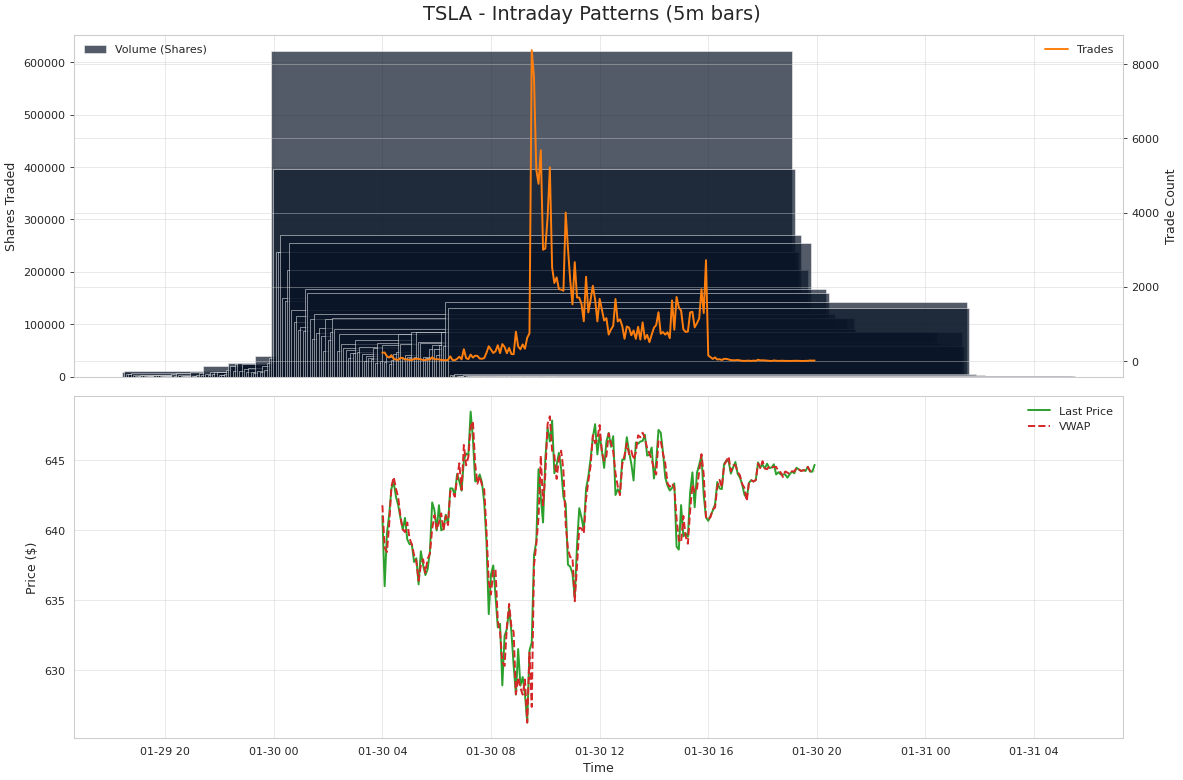

In [7]:
if data_available and all_trades is not None:
    print(f"High-Volume Ticker: {high_sym}")
    plot_intraday_bars(all_trades, high_sym, freq="5m")

Medium-Volume Ticker: PSTG


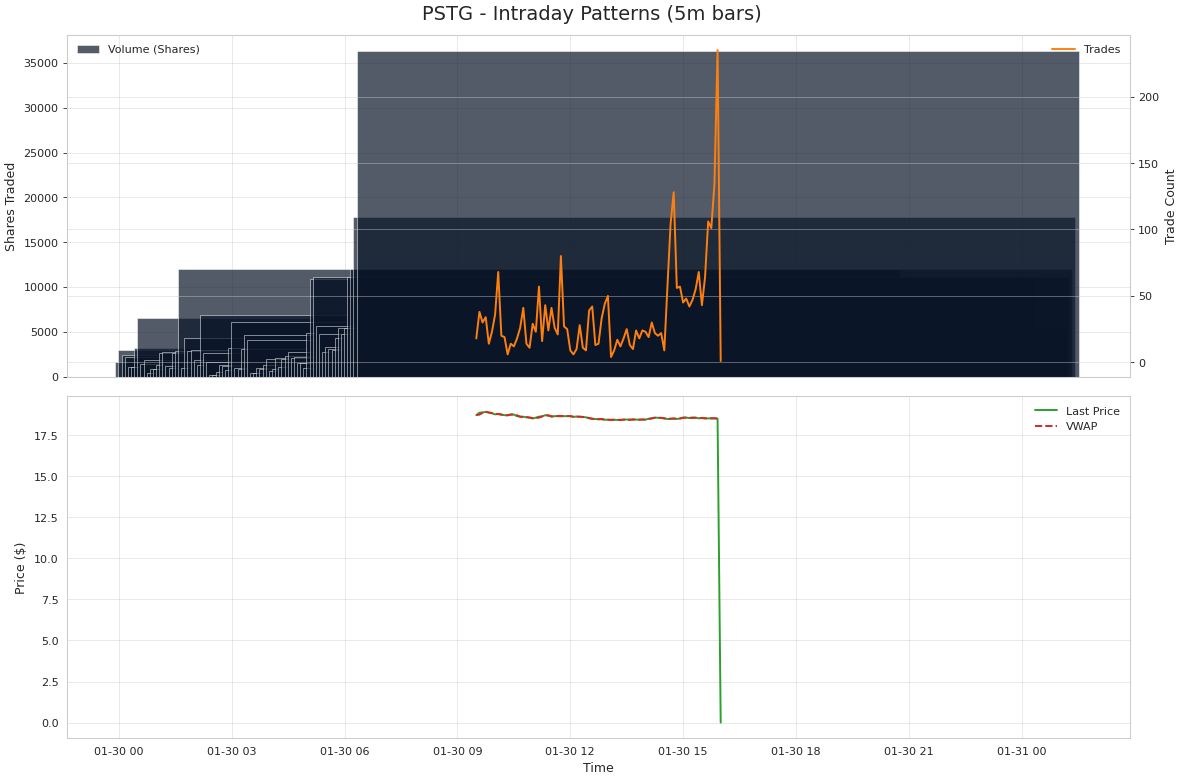

In [8]:
if data_available and all_trades is not None:
    print(f"Medium-Volume Ticker: {mid_sym}")
    plot_intraday_bars(all_trades, mid_sym, freq="5m")

Low-Volume Ticker: GNMX


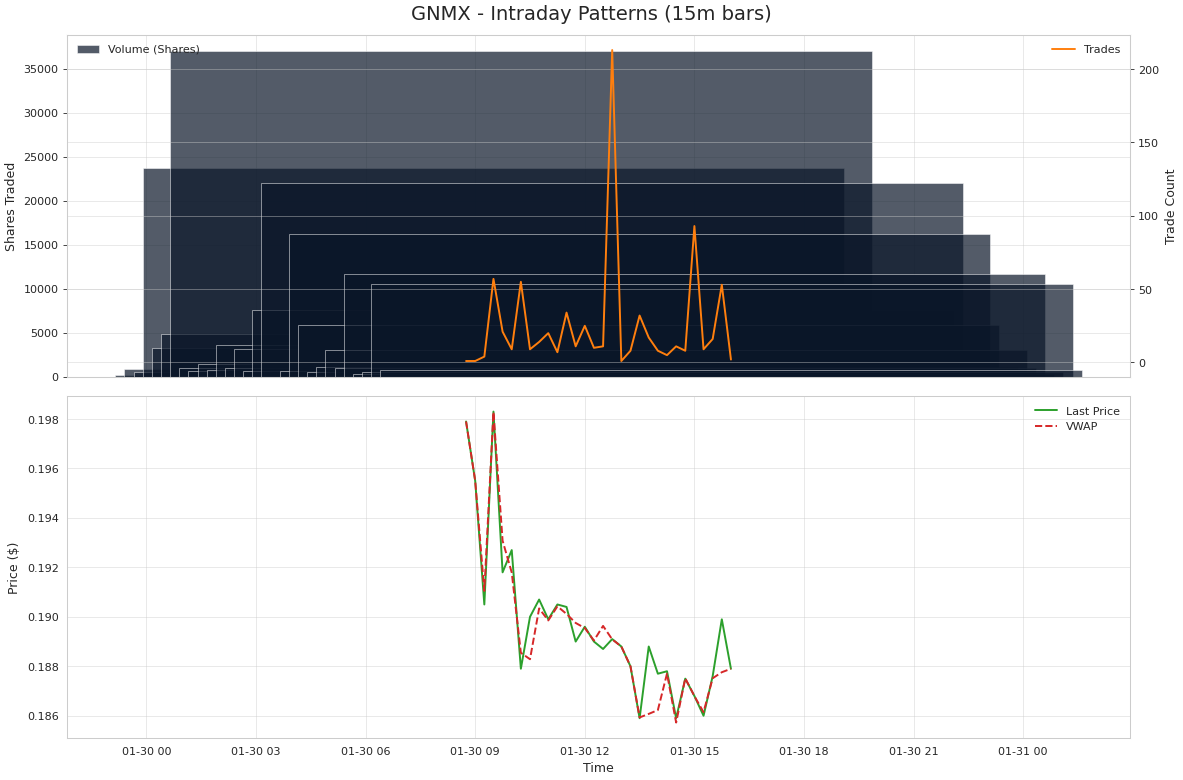

In [9]:
if data_available and all_trades is not None:
    print(f"Low-Volume Ticker: {low_sym}")
    plot_intraday_bars(all_trades, low_sym, freq="15m")  # Longer bars for sparse data


# ## 7. LOB Stylized Facts: Empirical Patterns
#
# This section demonstrates key empirical regularities in order flow data that motivate
# the microstructure features we construct in Chapter 8. These "stylized facts" are
# robust patterns observed across markets and time periods.

### 7.1 The Intraday U-Shape

Trading activity follows a characteristic U-shaped pattern throughout the day:
- **High at open**: Price discovery, overnight information incorporation
- **Low at midday**: "Lunch lull" with reduced institutional activity
- **High at close**: Portfolio rebalancing, index arbitrage, MOC orders

This pattern affects feature construction: time-of-day features capture these regularities.

In [10]:
def compute_intraday_pattern(
    trades_df: pl.DataFrame, tickers: list[str], freq: str = "30m"
) -> pl.DataFrame:
    """
    Compute average intraday patterns across multiple tickers.

    Args:
        trades_df: Canonical trades DataFrame from notebook 05
        tickers: List of stock symbols to analyze
        freq: Bar frequency (e.g., "30m")

    Returns:
        DataFrame with time_slot, vol_pct, trade_count, ticker
    """
    all_patterns = []

    for ticker in tickers:
        bars = intraday_resample(trades_df, ticker, freq)
        if len(bars) == 0:
            continue

        # Extract hour and compute relative metrics
        bars = bars.with_columns(
            pl.col("timestamp").dt.hour().alias("hour"),
            pl.col("timestamp").dt.minute().alias("minute"),
        )

        # Compute time-of-day slot (e.g., 9:30 -> 9.5)
        bars = bars.with_columns((pl.col("hour") + pl.col("minute") / 60).alias("time_slot"))

        # Normalize volume by total (to compare across tickers)
        # Note: For multi-day data, this normalizes by total across all days,
        # which gives average intraday pattern. For single-day data, this is daily total.
        total_vol = bars["shares"].sum()
        if total_vol > 0:
            bars = bars.with_columns(
                (pl.col("shares") / total_vol).alias("vol_pct"),
                pl.lit(ticker).alias("ticker"),
            )
            all_patterns.append(bars.select(["time_slot", "vol_pct", "trade_count", "ticker"]))

    if not all_patterns:
        return pl.DataFrame()

    return pl.concat(all_patterns)

In [11]:
if data_available and all_trades is not None:
    # Get top 20 liquid tickers for pattern analysis
    if TRADE_SUMMARY_PATH.exists():
        top_tickers = trade_summary.head(20)["ticker"].to_list()
    else:
        # Fallback to well-known liquid tickers
        top_tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "AMD"]

    pattern_df = compute_intraday_pattern(all_trades, top_tickers, freq="30m")

    if len(pattern_df) > 0:
        # Aggregate across tickers
        hourly_pattern = (
            pattern_df.group_by("time_slot")
            .agg(
                [
                    pl.col("vol_pct").mean().alias("avg_vol_pct"),
                    pl.col("vol_pct").std().alias("std_vol_pct"),
                    pl.col("trade_count").mean().alias("avg_trades"),
                ]
            )
            .sort("time_slot")
        )

        # Filter to regular trading hours (9:30-16:00)
        hourly_pattern = hourly_pattern.filter(
            (pl.col("time_slot") >= 9.5) & (pl.col("time_slot") <= 16)
        )

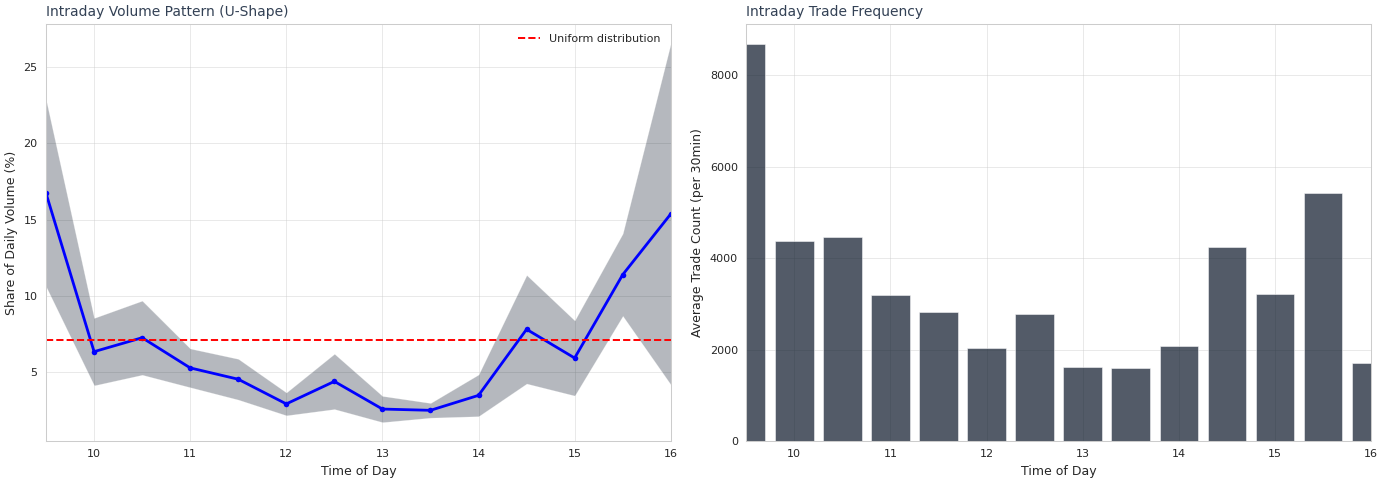

Intraday Volume Distribution:
  First 30min (9:30-10:00): 16.7% of daily volume
  Midday (12:00-12:30):     2.6% of daily volume
  Last 30min (15:30-16:00): 15.4% of daily volume
  Open/Close ratio to midday: 6.2x


In [12]:
if data_available and all_trades is not None:
    # Plot U-shape
    times = hourly_pattern["time_slot"].to_numpy()
    vol_pct = hourly_pattern["avg_vol_pct"].to_numpy() * 100
    vol_std = hourly_pattern["std_vol_pct"].to_numpy() * 100
    trades = hourly_pattern["avg_trades"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Volume U-shape
    axes[0].fill_between(times, vol_pct - vol_std, vol_pct + vol_std, alpha=0.3)
    axes[0].plot(times, vol_pct, "b-", linewidth=2, marker="o")
    axes[0].set_xlabel("Time of Day")
    axes[0].set_ylabel("Share of Daily Volume (%)")
    axes[0].set_title("Intraday Volume Pattern (U-Shape)")
    axes[0].axhline(100 / len(times), color="red", linestyle="--", label="Uniform distribution")
    axes[0].legend()
    axes[0].set_xlim(9.5, 16)

    # Trade count pattern
    axes[1].bar(times, trades, width=0.4, alpha=0.7)
    axes[1].set_xlabel("Time of Day")
    axes[1].set_ylabel("Average Trade Count (per 30min)")
    axes[1].set_title("Intraday Trade Frequency")
    axes[1].set_xlim(9.5, 16)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("Intraday Volume Distribution:")
    print(f"  First 30min (9:30-10:00): {vol_pct[0]:.1f}% of daily volume")
    print(f"  Midday (12:00-12:30):     {vol_pct[len(vol_pct) // 2]:.1f}% of daily volume")
    print(f"  Last 30min (15:30-16:00): {vol_pct[-1]:.1f}% of daily volume")
    print(
        f"  Open/Close ratio to midday: {(vol_pct[0] + vol_pct[-1]) / (2 * vol_pct[len(vol_pct) // 2]):.1f}x"
    )

## Key Takeaways

1. **Intraday U-shape**: Volume and trade frequency peak at the open and the
   close on the top-20 most active NASDAQ tickers in this sample.
2. **Scope**: The pattern is computed across the top-20 tickers and shown
   separately for one high-, one medium-, and one low-liquidity ticker; this
   notebook does not test how the shape varies systematically with liquidity.
3. **ML implications**: Time-of-day features capture this intraday variation.

**Next**: See `07_itch_stylized_facts` for bid-ask bounce and liquidity analysis.

---

## Reference

Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018).
*Trades, Quotes and Prices: Financial Markets Under the Microscope*.
Cambridge University Press.
[https://doi.org/10.1017/9781009028943](https://doi.org/10.1017/9781009028943)